# The temporal coherence fit 

Once the exponential fit has been generated, I can plot it in a couple different ways.  

In [21]:
# import libraries
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxa
import math
from rasterio.enums import Resampling
from rasterio.transform import rowcol
import rasterio
from datetime import datetime 

from pathlib import Path
from datetime import datetime
from time import time
import tifffile as tif

import matplotlib.pyplot as plt
import seaborn as sns

import sys
import os
scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)
from taus import decorrelation_temporal_model

In [27]:
BASE_DATADIR = '/bsuhome/julialober/scratch/comp_transfer/snowex_uavsar_coherence/data/snowex_lowman/'
FIG_DIR = '../outputs/figures/igarss_abstract/'

pilot_n = (43.955, -115.68)
pilot_s = (43.952, -115.685)
mcs_snotel = (43.9333, -115.6667)
pilot_n_color = 'green'
pilot_s_color = 'yellow'
mcs_snotel_color = 'turquoise'
pilot_n_marker = 'o'
pilot_s_marker = 's'
mcs_snotel_marker = '^'

plt.style.use('seaborn-v0_8')

In [22]:
# load the file with taus 
tau_file = BASE_DATADIR + 'taus/lowman_05208_tau_fixed_gamma.tif'

print(f"Loading {tau_file}... as `taus`")
taus = rxa.open_rasterio(tau_file)

Loading /bsuhome/julialober/scratch/comp_transfer/snowex_uavsar_coherence/data/snowex_lowman/taus/lowman_05208_tau_fixed_gamma.tif... as `taus`


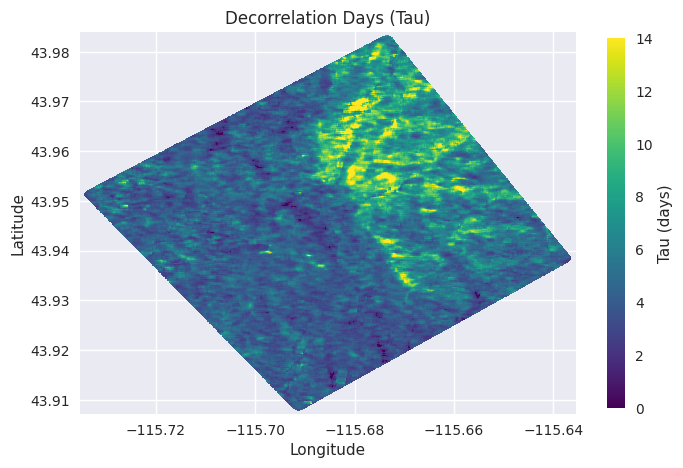

In [4]:
# plot taus 

fig, ax = plt.subplots(figsize=(8, 6))
taus_plot = taus.plot(ax=ax, cmap='viridis', vmin=0, vmax=14, add_colorbar=False)
# add points to map
# ax.plot(pilot_n[1], pilot_n[0], markersize=7, marker=pilot_n_marker, color=pilot_n_color, linestyle='None', label='High Tau')
# ax.plot(pilot_s[1], pilot_s[0], markersize=7, marker=pilot_s_marker, color=pilot_s_color, linestyle='None', label='Low Tau')
# ax.plot(mcs_snotel[1], mcs_snotel[0], markersize=8, marker=mcs_snotel_marker, color=mcs_snotel_color, linestyle='None', label='MCS SNOTEL')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)
# ax.legend(loc='lower right')
cbar = fig.colorbar(taus_plot, ax=ax, orientation='vertical', label='Tau (days)', shrink=0.8)
plt.title('Decorrelation Days (Tau)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# save figure
# fig.savefig(fig_dir + 'mores_creek_taus.png', dpi=300, bbox_inches='tight')

In [10]:
print(taus)

<xarray.DataArray (band: 1, y: 1435, x: 1864)> Size: 11MB
[2674840 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 15kB -115.7 -115.7 -115.7 ... -115.6 -115.6 -115.6
  * y            (y) float64 11kB 43.98 43.98 43.98 43.98 ... 43.91 43.91 43.91
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     nan
    scale_factor:   1.0
    add_offset:     0.0


In [11]:
# calculate 12 day coherence 
gamma_inf = 0.17
days = 12

# taus2 = taus.squeeze()
# taus_vals = taus2.values.astype(float)
# mask = np.isfinite(taus_vals) & (taus_vals > 0)

# taus_12day_da = np.full_like(taus_vals, np.nan, dtype=float)
# taus_12day_da[mask] = gamma_inf + (1 - gamma_inf) * np.exp(-days / taus_vals[mask])

# optional: return as xarray with same coords/dims
# taus_12day_da = xr.DataArray(taus_12day, coords=taus2.coords, dims=taus2.dims)
        # print(decorrelation_temporal_model(days, gamma_inf, taus[w, h]))
        # taus_12day[w, h] = decorrelation_temporal_model(days, gamma_inf, taus[w, h])

gamma_inf = 0.17
days = 12

# remove singleton band dim if present
taus2 = taus.squeeze()         # now shape (y, x)
h, w = taus2.shape
taus_12day_arr = np.full((h, w), np.nan, dtype=float)

for i in range(h):
    for j in range(w):
        tau = float(taus2.values[i, j])
        if np.isnan(tau) or tau <= 0:
            continue
        taus_12day_arr[i, j] = decorrelation_temporal_model(days, gamma_inf, tau)


NameError: name 'taus_12day_da' is not defined

In [12]:
taus_12day = taus.copy()
taus_12day.values[0] = taus_12day_arr
taus_12day.name = 'coherence_12day'

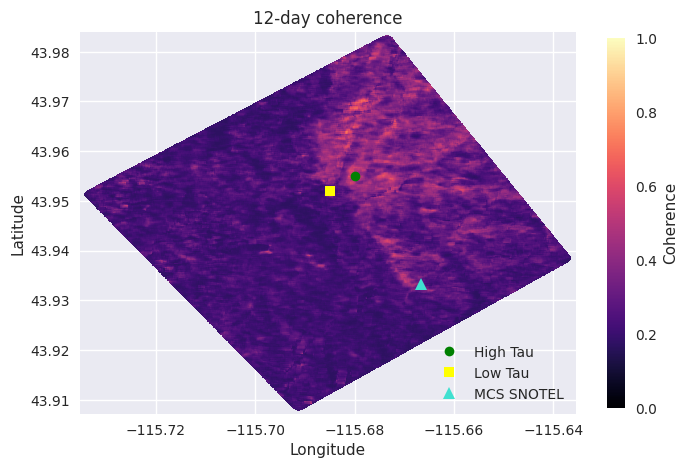

In [28]:
# plot 12 day taus 

fig, ax = plt.subplots(figsize=(8, 6))
taus_plot = taus_12day.plot(ax=ax, cmap='magma', vmin=0, vmax=1, add_colorbar=False)
# add points to map
ax.plot(pilot_n[1], pilot_n[0], markersize=7, marker=pilot_n_marker, color=pilot_n_color, linestyle='None', label='High Tau')
ax.plot(pilot_s[1], pilot_s[0], markersize=7, marker=pilot_s_marker, color=pilot_s_color, linestyle='None', label='Low Tau')
ax.plot(mcs_snotel[1], mcs_snotel[0], markersize=8, marker=mcs_snotel_marker, color=mcs_snotel_color, linestyle='None', label='MCS SNOTEL')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)
ax.legend(loc='lower right')
cbar = fig.colorbar(taus_plot, ax=ax, orientation='vertical', label='Coherence', shrink=0.8)
plt.title('12-day coherence')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

fig.savefig(FIG_DIR + 'mores_creek_12day_coherence.png', dpi=300, bbox_inches='tight')